# Dental X-ray Dataset: Merge + EDA

Combines two X-ray object-detection sources into one YOLO-bbox dataset scoped to the
sprint's 4-class list: **Cavity, Filling, Crown, Impacted Tooth**.

Sources:
- `data/raw/Dental X-ray.v1i.yolov11/` — axis-aligned YOLO bbox labels, 4 classes (Cavity, Fillings, Impacted Tooth, Implant)
- `data/raw/Dental X-Ray Panoramic Dataset/YOLO/YOLO/` — YOLO segmentation-polygon labels, 31 classes

The intraoral-photo "Cavity Dataset" is intentionally excluded — different imaging modality
(photos vs. X-ray), see `docs/README.md` for the reasoning.

Only instances belonging to the 4 target classes are kept. Polygons from the panoramic
source are converted to axis-aligned boxes (min/max of the polygon points). Images left
with zero target-class instances after filtering are dropped.

The actual merge/parsing logic lives in `src/data/prepare_dataset.py` and `src/data/eda.py`
(reusable, per the repo's `src/README.md` conventions) — this notebook just calls into it.

## 1. Environment setup

Run this cell first. It detects whether you're on Colab or running locally:

- **Colab**: clones this repo (for the `src/` code), mounts your Google Drive, then
  copies+extracts the two dataset zips from `MyDrive/Dental Cavity Detection/` into local
  Colab disk — reading thousands of small files directly off Drive is very slow.
- **Local**: locates the repo root (looks for `requirements.txt` + `src/`) and reads data
  straight from `data/raw/`, matching `data/README.md`.

In [1]:
import subprocess
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/neuroarcane/dental-cavity-detector.git"
    REPO_ROOT = Path("/content/dental-cavity-detector")
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull"], check=True)

    from google.colab import drive
    drive.mount("/content/drive")
else:
    def _find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "requirements.txt").exists() and (parent / "src").exists():
                return parent
        raise RuntimeError("Could not locate repo root (looked for requirements.txt + src/)")

    REPO_ROOT = _find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"IN_COLAB = {IN_COLAB}")
print(f"REPO_ROOT = {REPO_ROOT}")

IN_COLAB = False
REPO_ROOT = /Users/varsha/Documents/dental-cavity-detector


## 2. Imports

In [2]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from src.data.config import DATA_PROCESSED, TARGET_CLASSES
from src.data.prepare_dataset import merge_datasets, print_merge_summary
from src.data.eda import load_annotations, load_image_metadata

%matplotlib inline
pd.set_option("display.max_columns", None)

## 3. Run the merge

Rebuilds `data/processed/` from `data/raw/` each time (on Colab, this also extracts the
dataset zips from Drive first if not already done this session).

In [3]:
stats = merge_datasets()
print_merge_summary(stats)
print(f"\nCombined dataset written to: {DATA_PROCESSED}")

Source A classes kept: {'Cavity': 'Cavity', 'Fillings': 'Filling', 'Impacted Tooth': 'Impacted Tooth'}
Source B classes kept: {'Caries': 'Cavity', 'Crown': 'Crown', 'Filling': 'Filling', 'impacted tooth': 'Impacted Tooth'}

train: seen=10234 kept=10023 dropped(no target-class objects)=211
valid: seen=3086 kept=3044 dropped(no target-class objects)=42
test: seen=1687 kept=1665 dropped(no target-class objects)=22

Instance counts (target classes only):
  Cavity: 11300
  Filling: 54270
  Crown: 11252
  Impacted Tooth: 28406

Combined dataset written to: /Users/varsha/Documents/dental-cavity-detector/data/processed


## 4. EDA on the combined dataset

Filenames are prefixed by source dataset (`xray1_...` or `panoramic_...`) so we can also
compare distributions across the two merged sources.

In [4]:
annotations = load_annotations()
images = load_image_metadata()
print(f"{len(images)} images, {len(annotations)} object instances loaded")

14732 images, 105228 object instances loaded


### Image counts per split / source

In [5]:
images.groupby(["split", "source"]).size().unstack(fill_value=0)

source,panoramic,xray1
split,,
test,1569,96
train,9295,728
valid,2839,205


### Corrupt / unreadable images

In [6]:
corrupt = images[images["corrupt"]]
print(f"{len(corrupt)} corrupt image(s)" if len(corrupt) else "None found")
corrupt

None found


,split,source,image,width,height,corrupt


### Image resolution stats by source

In [7]:
images.groupby("source")[["width", "height"]].describe()

width                                                        \
             count         mean         std    min    25%    50%     75%   
source                                                                     
panoramic  13703.0  1028.064657  477.268777  640.0  640.0  640.0  1615.0   
xray1       1029.0   640.000000    0.000000  640.0  640.0  640.0   640.0   

                    height                                                     \
              max    count        mean        std    min    25%    50%    75%   
source                                                                          
panoramic  1615.0  13703.0  719.603007  97.901288  640.0  640.0  640.0  840.0   
xray1       640.0   1029.0  640.000000   0.000000  640.0  640.0  640.0  640.0   

                  
             max  
source            
panoramic  840.0  
xray1      640.0

### Class balance per split

In [8]:
pd.crosstab(annotations["split"], annotations["class"])

class,Cavity,Crown,Filling,Impacted Tooth
split,,,,
test,1228,1157,6133,3300
train,7748,8008,37005,19179
valid,2324,2087,11132,5927


### Class balance by source dataset

This is the key sanity check for the merge: `xray1` contributes zero `Crown` labels, and the two sources are very unevenly sized, so any train/val/test split should be stratified by source, not just shuffled.

In [9]:
pd.crosstab(annotations["source"], annotations["class"])

class,Cavity,Crown,Filling,Impacted Tooth
source,,,,
panoramic,10724,11252,49031,27978
xray1,576,0,5239,428


### Bounding box size stats (normalized 0-1)

In [10]:
annotations.groupby("class")[["bbox_w", "bbox_h", "bbox_area_norm"]].describe()

bbox_w                                                    \
                  count      mean       std       min       25%       50%   
class                                                                       
Cavity          11300.0  0.022434  0.016178  0.003086  0.011077  0.017259   
Crown           11252.0  0.052403  0.029602  0.001005  0.036002  0.047264   
Filling         54270.0  0.041006  0.017342  0.000352  0.030764  0.040179   
Impacted Tooth  28406.0  0.075149  0.022514  0.020309  0.059784  0.073144   

                                     bbox_h                                \
                     75%       max    count      mean       std       min   
class                                                                       
Cavity          0.028916  0.358323  11300.0  0.049264  0.032911  0.004788   
Crown           0.058891  0.490865  11252.0  0.077966  0.016496  0.022283   
Filling         0.050105  1.047532  54270.0  0.065139  0.042884  0.003906   
Impacted Tooth  0.086861  0.423231  28406.0  0.128353  0.023447  0.022136   

                                                       bbox_area_norm  \
                     25%       50%       75%       max          count   
class                                                                   
Cavity          0.029277  0.041078  0.058590  0.261719        11300.0   
Crown           0.067597  0.076594  0.086483  0.199825        11252.0   
Filling         0.038511  0.053527  0.076000  0.900211        54270.0   
Impacted Tooth  0.110392  0.125881  0.144531  0.270008        28406.0   

                                                                            \
                    mean       std       min       25%       50%       75%   
class                                                                        
Cavity          0.001422  0.001988  0.000041  0.000340  0.000688  0.001655   
Crown           0.004277  0.003722  0.000022  0.002639  0.003512  0.004700   
Filling         0.002948  0.004857  0.000003  0.001279  0.002163  0.003656   
Impacted Tooth  0.009665  0.003576  0.000701  0.007313  0.008920  0.011190   

                          
                     max  
class                     
Cavity          0.020452  
Crown           0.082656  
Filling         0.943000  
Impacted Tooth  0.055609

### Plots: class balance

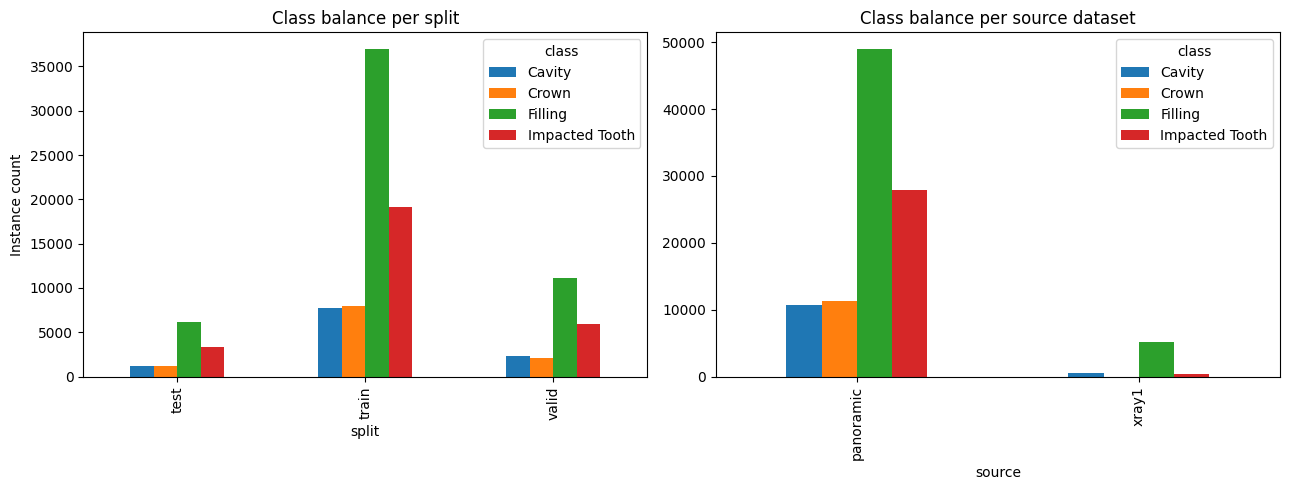

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

annotations.groupby(["split", "class"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance per split")
axes[0].set_ylabel("Instance count")

annotations.groupby(["source", "class"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[1])
axes[1].set_title("Class balance per source dataset")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_class_balance.png")
plt.show()

### Plots: image quality

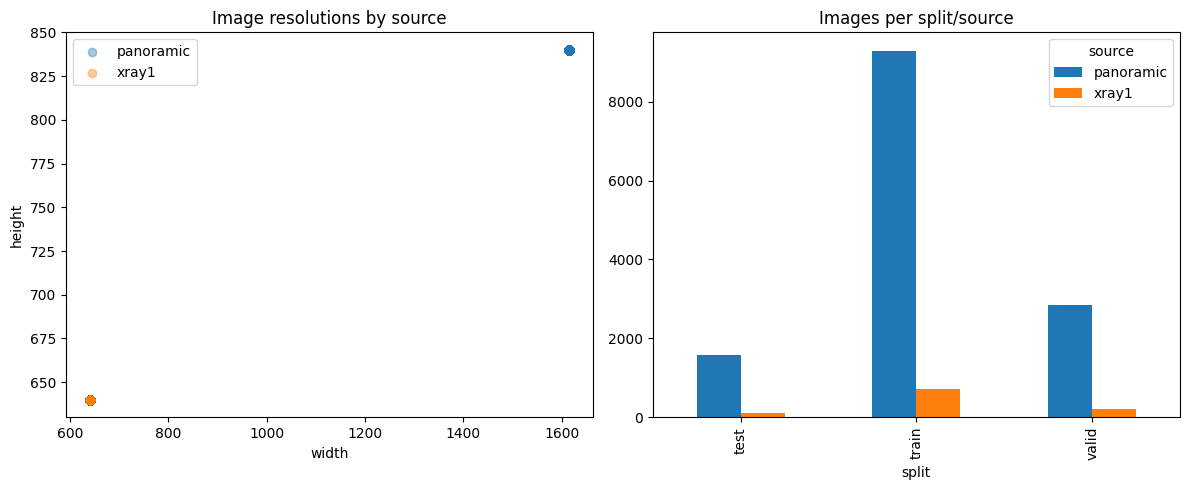

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for source, group in images.groupby("source"):
    axes[0].scatter(group["width"], group["height"], alpha=0.4, label=source)
axes[0].set_xlabel("width")
axes[0].set_ylabel("height")
axes[0].set_title("Image resolutions by source")
axes[0].legend()

images.groupby(["split", "source"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[1])
axes[1].set_title("Images per split/source")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_image_quality.png")
plt.show()

### Sample images with boxes drawn

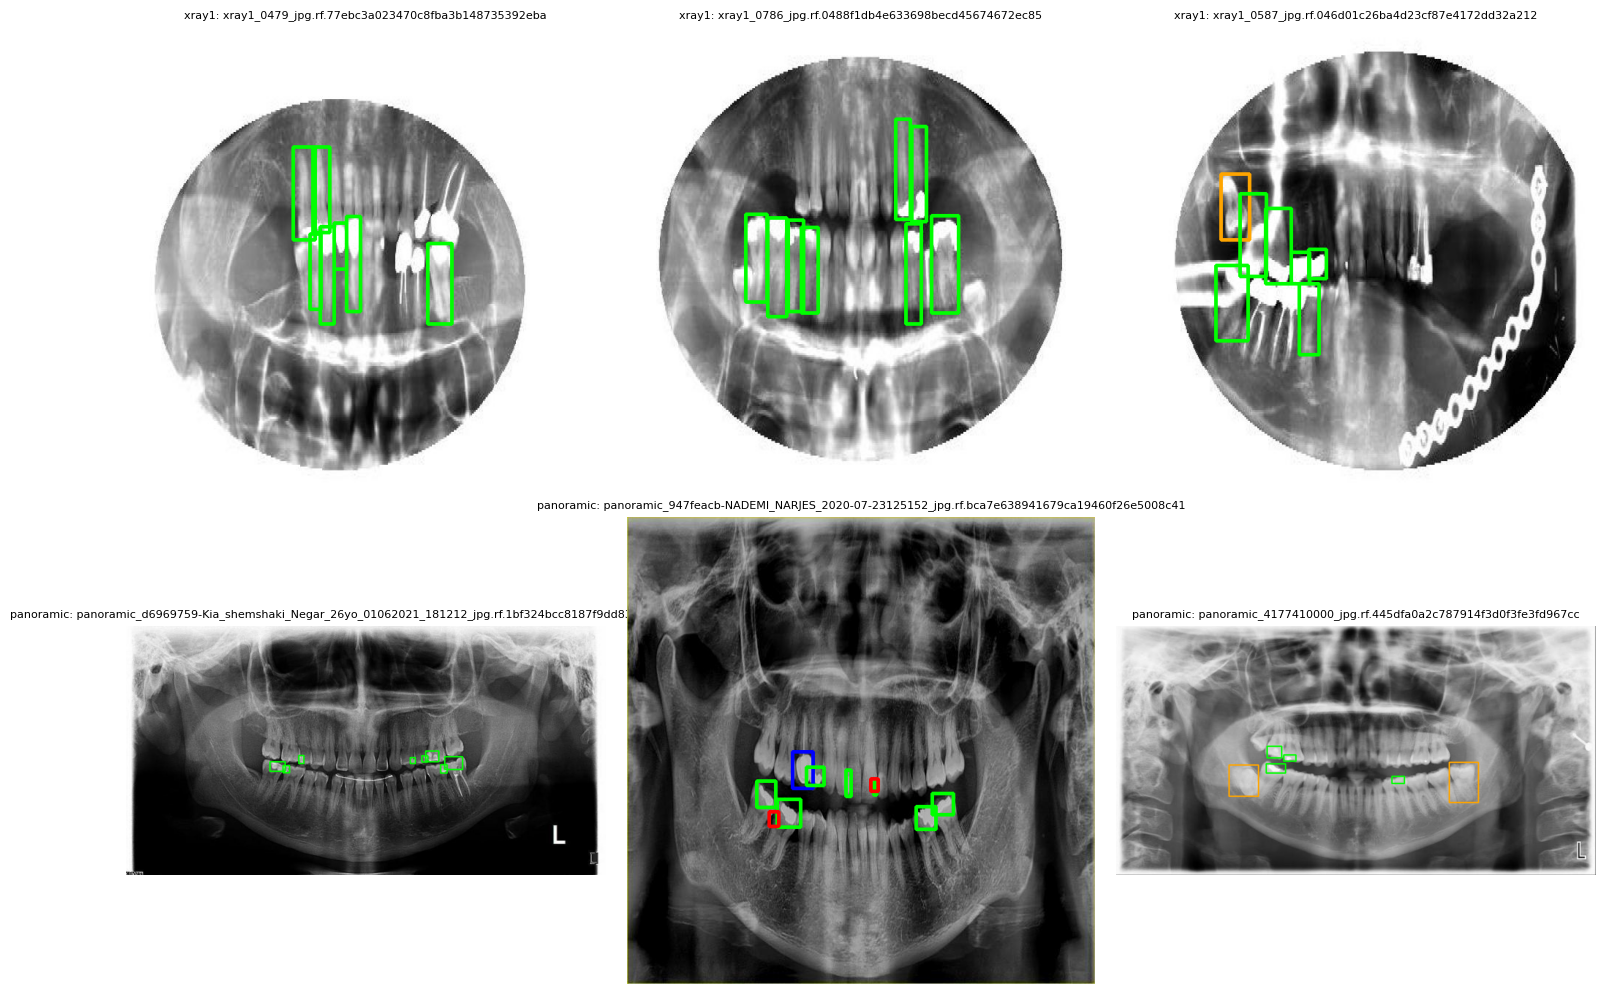

In [13]:
def draw_boxes(image_path, boxes):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    colors = {"Cavity": (255, 0, 0), "Filling": (0, 255, 0), "Crown": (0, 0, 255), "Impacted Tooth": (255, 165, 0)}
    for _, row in boxes.iterrows():
        x1 = int((row["x_center"] - row["bbox_w"] / 2) * w)
        y1 = int((row["y_center"] - row["bbox_h"] / 2) * h)
        x2 = int((row["x_center"] + row["bbox_w"] / 2) * w)
        y2 = int((row["y_center"] + row["bbox_h"] / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), colors[row["class"]], 3)
    return img


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_i, source in enumerate(["xray1", "panoramic"]):
    sample_images = annotations[annotations["source"] == source]["image"].unique()[:3]
    for col_i, image_name in enumerate(sample_images):
        boxes = annotations[annotations["image"] == image_name]
        img = draw_boxes(boxes.iloc[0]["image_path"], boxes)
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"{source}: {image_name}", fontsize=8)
        axes[row_i, col_i].axis("off")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_sample_boxes.png")
plt.show()

### Save outputs

In [14]:
annotations.to_csv(DATA_PROCESSED / "annotations_long.csv", index=False)
images.to_csv(DATA_PROCESSED / "image_metadata.csv", index=False)
print("Saved annotations_long.csv and image_metadata.csv")

Saved annotations_long.csv and image_metadata.csv


## 5. Key findings

- **Source imbalance**: the panoramic dataset dominates ~13:1 in image count over `xray1`, and supplies nearly all `Crown` instances — `xray1` contributes zero. Splitting/evaluating without stratifying by source will mostly measure performance on panoramic images.
- **Class imbalance**: `Filling` instances (~54k) outnumber `Cavity` and `Crown` (~11k each) by roughly 5:1 — expect a baseline model to be biased toward predicting Filling.
- **Resolution mismatch**: `xray1` images are uniformly 640x640 (pre-resized by Roboflow); panoramic images vary between 640-840px per side.

Worth raising with the team before the baseline YOLO run: whether to stratify sampling by source, and whether to apply class-weighted loss or oversampling for Cavity/Crown.